## 0 - Extra information, goals, equations, terms

**Order book:** electronic list of buy and sell orders for a specific security or financial instrument organized by price level; lists the number of shares being bid on or offered at each price point
- **Bid:** intended buy orders
- **Offer/ask** intended sell orders

**Order book statistics:**
- **bid/ask spread:** ratio of best offer price (lowest offer) and best bid price (highest bid)
$$BidAskSpread = BestOffer/BestBid -1$$
- **Weighted averaged price:** used to calculate instantaneous stock valuation and calculate realized volatility
$$ WAP = \frac{BidPrice_{1}*AskSize_{1} + AskPrice_{1}*BidSize_{1}}{BidSize_{1} + AskSize_{1}} $$

- **Log returns:** used to compare the price of a stock between 2 times
    - stock return = percentage change in price
- $$r_{t_1, t_2} = \log \left( \frac{S_{t_2}}{S_{t_1}} \right)$$
    - St represents price of stock S at time t
    - With 10-min log return, $r_t = r_{t - 10 min, t}$
- **Realized volatility:** squared root of the sum of the squared log returns
    - The annualized standard deviation of the stock log returns is called volatility
$$
\sigma = \sqrt{\sum_{t}r_{t-1, t}^2}
$$
- For this competition, using WAP as price of the stock to compute log returns


**Goal:** Generate series of short-term signals from book and trade data of a fixed 10-minute window to predict the realized volatility of the next 10-minute window

**Data:** 
- book_train.parquet and book_test.parquet --> order book data, snapshots of top 2 price levels of order book during each 10 minute window
- trade_train.parquet and trade_test.parquet --> trades that happened in each 10 minute window, organized same way as order book data
- train.csv --> actual realized volatility for next 10 minutes, contains target
- test.csv --> rows you need to predict

## 1 - Naive prediction from introduction notebook
Predicting realized volatility by using whatever the realized volatility was in the initial 10 minutes
Predicted volatility for the next 10 min = realized volatility of the past 10 min

In [1]:
import numpy as np
import pandas as pd

#helper functions

def calc_wap1(df):
    return (df['bid_price1'] * df['ask_size1'] +df['ask_price1'] * df['bid_size1']) / (
    df['bid_size1']+ df['ask_size1'])
    
def log_return(list_stock_prices):
    return np.log(list_stock_prices).diff()

def realized_volatility(series_log_return):
    return np.sqrt(np.sum(series_log_return**2))

In [2]:
import os
from sklearn.metrics import r2_score
import glob

#data location: search /kaggle/input for the competition files (exact mount path can vary), local folder otherwise
def find_data_dir():
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train.csv' in files and 'book_train.parquet' in dirs:
            return root
    return 'optiver-realized-volatility-prediction'

DATA_DIR = find_data_dir()
print('DATA_DIR:', DATA_DIR, '| files:', os.listdir(DATA_DIR))

list_order_book_file_train = glob.glob(f'{DATA_DIR}/book_train.parquet/*')

In [3]:
#past realized volatility across training set

#load book data, compute wap1, compute log returns within each window, then compute realized volatility
def realized_volatility_per_time_id(file_path, prediction_column_name):
    df_book_data = pd.read_parquet(file_path)
    df_book_data['wap1'] = calc_wap1(df_book_data)
    df_book_data['log_return'] = df_book_data.groupby(['time_id'], group_keys = False)['wap1'].apply(log_return)
    df_book_data = df_book_data[~df_book_data['log_return'].isnull()]
    df_realized_vol_per_stock =  pd.DataFrame(df_book_data.groupby(['time_id'])['log_return'].agg(realized_volatility)).reset_index()
    df_realized_vol_per_stock = df_realized_vol_per_stock.rename(columns = {'log_return':prediction_column_name})
    stock_id = file_path.split('=')[1]
    df_realized_vol_per_stock['row_id'] = df_realized_vol_per_stock['time_id'].apply(lambda x:f'{stock_id}-{x}') #build row id to match train.csv
    return df_realized_vol_per_stock[['row_id',prediction_column_name]]

def past_realized_volatility_per_stock(list_file,prediction_column_name):
    df_past_realized = pd.DataFrame()
    for file in list_file:
        df_past_realized = pd.concat([df_past_realized, realized_volatility_per_time_id(file,prediction_column_name)])
    return df_past_realized
df_past_realized_train = past_realized_volatility_per_stock(list_file=list_order_book_file_train, prediction_column_name='past_rv')
df_past_realized_train.head(10)

,row_id,past_rv
0,17-5,0.004091
1,17-11,0.002155
2,17-16,0.002566
3,17-31,0.002221
4,17-62,0.002155
5,17-72,0.008016
6,17-97,0.007457
7,17-103,0.005526
8,17-109,0.003243
9,17-123,0.002520


In [4]:
#join df_past_realized_train with train.csv to see performance of naive prediction on training set
#train contains the actual rv for the next 10 minutes
train = pd.read_csv(f'{DATA_DIR}/train.csv')
train['row_id'] = train['stock_id'].astype(str) + '-' + train['time_id'].astype(str)
train = train[['row_id','target']]
df_joined = train.merge(df_past_realized_train[['row_id','past_rv']], on = ['row_id'], how = 'left')
df_joined

,row_id,target,past_rv
0,0-5,0.004136,0.004499
1,0-11,0.001445,0.001204
2,0-16,0.002168,0.002369
3,0-31,0.002195,0.002574
4,0-62,0.001747,0.001894
...,...,...,...
428927,126-32751,0.003461,0.003691
428928,126-32753,0.003113,0.004104
428929,126-32758,0.004070,0.003117
428930,126-32763,0.003357,0.003661


In [5]:
#evaluate prediction
from sklearn.metrics import r2_score
def rmspe(y_true, y_pred):
    return  (np.sqrt(np.mean(np.square((y_true - y_pred) / y_true))))
R2 = round(r2_score(y_true = df_joined['target'], y_pred = df_joined['past_rv']),3)
RMSPE = round(rmspe(y_true = df_joined['target'], y_pred = df_joined['past_rv']),3)
print(f'Performance of the naive prediction: R2 score: {R2}, RMSPE: {RMSPE}')

Performance of the naive prediction: R2 score: 0.628, RMSPE: 0.341


## 2 - Linear Regression on log past realized volatility

Predicting next 10 min vol from past 10 min vol.

Target:
train.csv (y) holds the target --> data and realized volatility of the next 10 mins

Predictors:
book_train.parquet (x) holds book snapshots from first 10 mins --> calculate past realized volatility

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold

df = df_joined.dropna().copy()
df['time_id'] = df['row_id'].str.split('-').str[1].astype(int)

#use log vals
X = np.log(df[['past_rv']].values)
y = np.log(df['target'].values)

#split by time id so same 10-min window doesn't appear in train and validation
oof = np.zeros(len(df)) # out of fold
#rows split intp 5 folds, all rows with same time_id in same fold, gives you training and validating data, fit new model on train, predicts validation rows, puts predictions in oof
for tr, va in GroupKFold(n_splits=5).split(X, y, groups = df['time_id']):
    model = LinearRegression().fit(X[tr], y[tr])
    oof[va] = model.predict(X[va])

In [7]:
df['lr_pred'] = np.exp(oof)
print(f"Linear regression: R2 {r2_score(df['target'], df['lr_pred']):.3f}, "f"RMSPE {rmspe(df['target'], df['lr_pred']):.3f}")

#final model on all data
model = LinearRegression().fit(X, y)
print(f"log(target) = {model.intercept_:.3f} + {model.coef_[0]:.3f} * log(past_vol)")
df

Linear regression: R2 0.774, RMSPE 0.287
log(target) = -0.875 + 0.856 * log(past_vol)


,row_id,target,past_rv,time_id,lr_pred
0,0-5,0.004136,0.004499,5,0.004087
1,0-11,0.001445,0.001204,11,0.001316
2,0-16,0.002168,0.002369,16,0.002359
3,0-31,0.002195,0.002574,31,0.002538
4,0-62,0.001747,0.001894,62,0.001946
...,...,...,...,...,...
428927,126-32751,0.003461,0.003691,32751,0.003434
428928,126-32753,0.003113,0.004104,32753,0.003772
428929,126-32758,0.004070,0.003117,32758,0.002990
428930,126-32763,0.003357,0.003661,32763,0.003421


## 3 - Feature engineering

- Past realized volatility over smaller windows (past 5 mins, past 2 mins)
- Past realized volatility calculated from WAP2 --> WAP computed from 2nd best bid and ask
- Bid ask spread: ask_price1/bid_price1 - 1 --> wide spread means buyers and sellers disagree about price, which tend to come before bigger price moves
- Trade count and volume --> whether trading activity is high
- Realized volatility of trade prices --> using actual trade prices instead of WAP
- Average realized volatility across all stocks in the same time_id



In [8]:
#wap2 helper function

def calc_wap2(df):
    return (df['bid_price2'] * df['ask_size2'] + df['ask_price2'] * df['bid_size2']) / (
    df['bid_size2'] + df['ask_size2'])

In [9]:
#book features: past realized vol over small windows, realized vol from wap1 and wap2, bid ask spread

def book_features_per_time_id(file_path):
    df = pd.read_parquet(file_path)

    #log returns of wap1 and wap2 within each time_id
    df['log_return1'] = df.assign(wap1 = calc_wap1(df)).groupby('time_id')['wap1'].transform(log_return)
    df['log_return2'] = df.assign(wap2 = calc_wap2(df)).groupby('time_id')['wap2'].transform(log_return)

    #keep only returns from the last 5 / last 2 minutes (earlier ones become NaN and are skipped)
    df['log_return1_5min'] = df['log_return1'].where(df['seconds_in_bucket'] >= 300)
    df['log_return1_2min'] = df['log_return1'].where(df['seconds_in_bucket'] >= 480)

    #bid ask spread: best offer / best bid - 1
    df['bid_ask_spread'] = df['ask_price1'] / df['bid_price1'] - 1

    df_features = df.groupby('time_id').agg(
        rv_wap1 = ('log_return1', realized_volatility),
        rv_wap2 = ('log_return2', realized_volatility),
        rv_wap1_5min = ('log_return1_5min', realized_volatility),
        rv_wap1_2min = ('log_return1_2min', realized_volatility),
        bid_ask_spread_mean = ('bid_ask_spread', 'mean'),
        bid_ask_spread_max = ('bid_ask_spread', 'max'),
    ).reset_index()

    stock_id = file_path.split('=')[1]
    df_features['row_id'] = stock_id + '-' + df_features['time_id'].astype(str)
    return df_features.drop(columns = 'time_id')

df_book_features_train = pd.concat([book_features_per_time_id(f) for f in list_order_book_file_train], ignore_index = True)
df_book_features_train.head(10)

,rv_wap1,rv_wap2,rv_wap1_5min,rv_wap1_2min,bid_ask_spread_mean,bid_ask_spread_max,row_id
0,0.004091,0.005673,0.003056,0.001807,0.000523,0.001157,17-5
1,0.002155,0.003741,0.001696,0.000877,0.000419,0.001132,17-11
2,0.002566,0.003324,0.001810,0.001174,0.000406,0.000819,17-16
3,0.002221,0.003017,0.001501,0.001136,0.000457,0.000993,17-31
4,0.002155,0.003315,0.001495,0.001166,0.000304,0.000603,17-62
5,0.008016,0.010084,0.006855,0.004126,0.001001,0.002423,17-72
6,0.007457,0.009994,0.005752,0.004217,0.000848,0.001736,17-97
7,0.005526,0.009423,0.003774,0.001932,0.000665,0.001673,17-103
8,0.003243,0.004406,0.002255,0.001563,0.000415,0.000813,17-109
9,0.002520,0.003380,0.001639,0.001074,0.000316,0.000648,17-123


In [10]:
#trade features: trade count, trade volume, rv of trade, 
list_trade_file_train = glob.glob(f'{DATA_DIR}/trade_train.parquet/*')

def trade_features_per_time_id(file_path):
    df = pd.read_parquet(file_path)
    df['log_return'] = df.groupby('time_id')['price'].transform(log_return)

    df_features = df.groupby('time_id').agg(
        rv_trade = ('log_return', realized_volatility),
        trade_count = ('seconds_in_bucket', 'count'),
        trade_volume = ('size', 'sum'),
        trade_order_count = ('order_count', 'sum'),
    ).reset_index()

    stock_id = file_path.split('=')[1]
    df_features['row_id'] = stock_id + '-' + df_features['time_id'].astype(str)
    return df_features.drop(columns = 'time_id')

df_trade_features_train = pd.concat([trade_features_per_time_id(f) for f in list_trade_file_train], ignore_index = True)
df_trade_features_train.head(10)

,rv_trade,trade_count,trade_volume,trade_order_count,row_id
0,0.002113,77,6466,193,17-5
1,0.001258,30,3347,105,17-11
2,0.001105,30,3065,73,17-16
3,0.001089,23,669,47,17-31
4,0.001005,34,2947,106,17-62
5,0.003393,77,10755,266,17-72
6,0.004313,79,12094,218,17-97
7,0.002556,53,6414,146,17-103
8,0.002083,54,8375,160,17-109
9,0.001918,104,18871,318,17-123


In [11]:
#merge book, trade, and target features into one df

df_features_train = (train.merge(df_book_features_train, on = 'row_id', how = 'left').merge(df_trade_features_train, on = 'row_id', how = 'left'))

#windows with no trades
trade_cols = ['rv_trade', 'trade_count', 'trade_volume', 'trade_order_count']
df_features_train[trade_cols] = df_features_train[trade_cols].fillna(0)

#recover ids from row_id
df_features_train['stock_id'] = df_features_train['row_id'].str.split('-').str[0].astype(int)
df_features_train['time_id'] = df_features_train['row_id'].str.split('-').str[1].astype(int)

#market-wide feature: average rv across all stocks in the same 10-min window
df_features_train['market_rv'] = df_features_train.groupby('time_id')['rv_wap1'].transform('mean')

df_features_train.to_parquet('features_train.parquet')
df_features_train.head()

,row_id,target,rv_wap1,rv_wap2,rv_wap1_5min,rv_wap1_2min,bid_ask_spread_mean,bid_ask_spread_max,rv_trade,trade_count,trade_volume,trade_order_count,stock_id,time_id,market_rv
0,0-5,0.004136,0.004499,0.006999,0.002953,0.001467,0.000852,0.001394,0.002006,40.0,3179.0,110.0,0,5,0.004583
1,0-11,0.001445,0.001204,0.002476,0.000981,0.000896,0.000394,0.000904,0.000901,30.0,1289.0,57.0,0,11,0.002206
2,0-16,0.002168,0.002369,0.004801,0.001295,0.000775,0.000725,0.001150,0.001961,25.0,2161.0,68.0,0,16,0.002289
3,0-31,0.002195,0.002574,0.003637,0.001776,0.000987,0.000861,0.001624,0.001561,15.0,1962.0,59.0,0,31,0.002598
4,0-62,0.001747,0.001894,0.003257,0.001520,0.001154,0.000397,0.000793,0.000871,22.0,1791.0,89.0,0,62,0.002041


## 4 - Distributions of engineered features

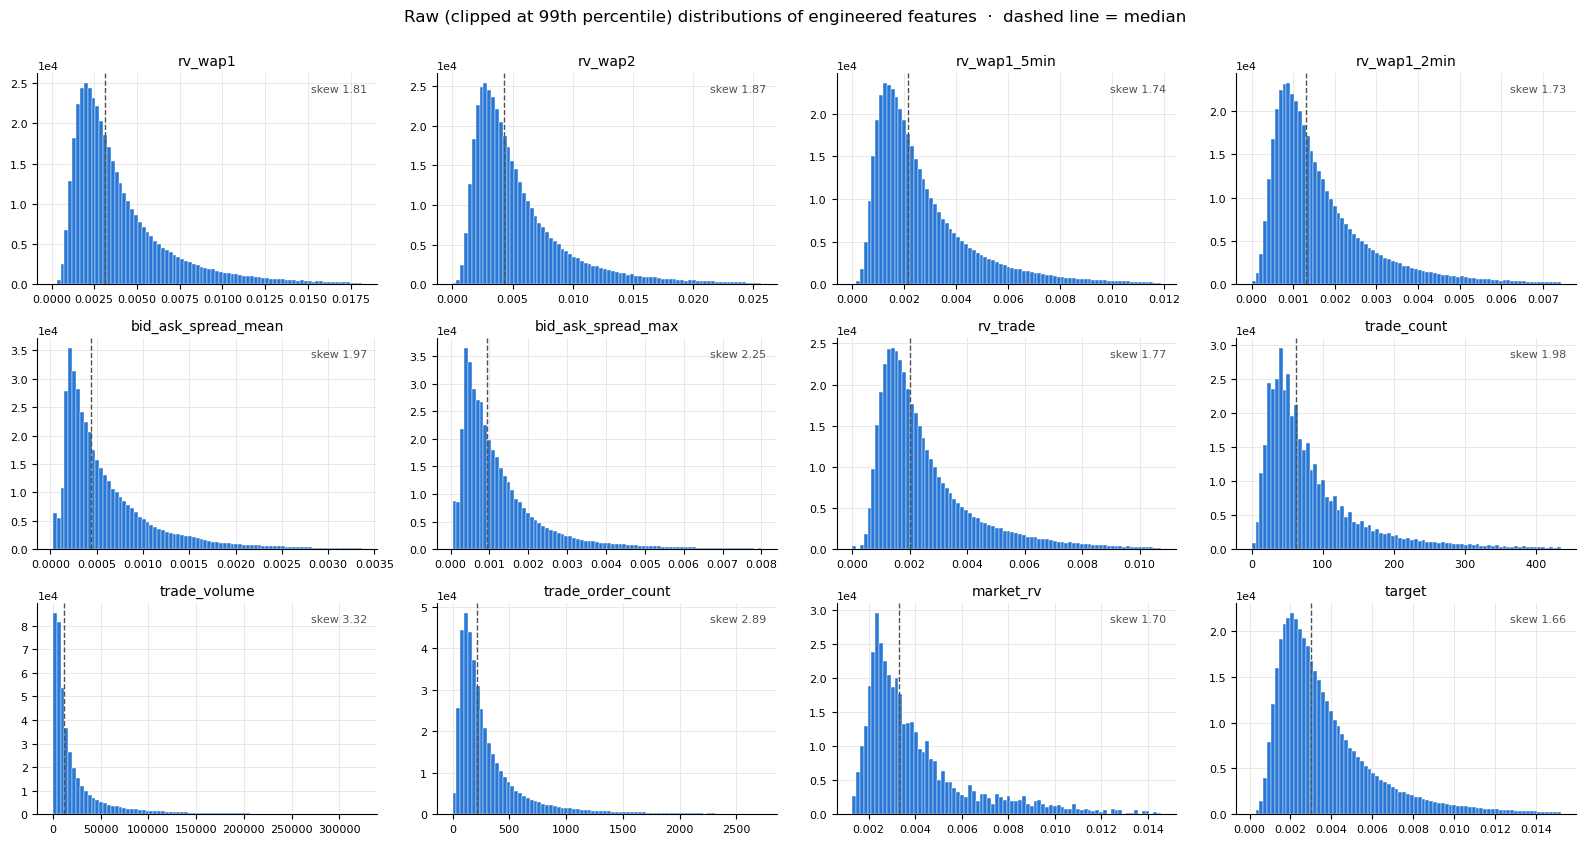

In [12]:
import matplotlib.pyplot as plt

plot_cols = ['rv_wap1', 'rv_wap2', 'rv_wap1_5min', 'rv_wap1_2min',
             'bid_ask_spread_mean', 'bid_ask_spread_max',
             'rv_trade', 'trade_count', 'trade_volume', 'trade_order_count',
             'market_rv', 'target']

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e5e5e5', 'grid.linewidth': 0.6,
                     'axes.axisbelow': True, 'axes.titlesize': 10, 'axes.labelsize': 9,
                     'xtick.labelsize': 8, 'ytick.labelsize': 8})
BLUE = '#2a78d6'
MUTED = '#52514e'

def plot_distributions(df, cols, log = False, ncols = 4):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize = (4 * ncols, 2.8 * nrows))
    for ax, col in zip(axes.flat, cols):
        s = df[col].dropna()
        n_zero = (s <= 0).sum()
        if log:
            #log undefined at 0 (e.g. windows with no trades): drop and report them
            s = np.log(s[s > 0])
        else:
            #clip the long right tail so the bulk of the distribution is visible
            s = s[s <= s.quantile(0.99)]
        ax.hist(s, bins = 80, color = BLUE, edgecolor = 'white', linewidth = 0.3)
        ax.axvline(s.median(), color = MUTED, linestyle = '--', linewidth = 1)
        ax.set_title(f'log({col})' if log else col)
        note = f'skew {s.skew():.2f}'
        if n_zero and log:
            note += f'\n{n_zero:,} zeros dropped'
        ax.text(0.97, 0.95, note, transform = ax.transAxes, ha = 'right', va = 'top',
                fontsize = 8, color = MUTED)
        ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 3))
    for ax in axes.flat[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(('Log-transformed' if log else 'Raw (clipped at 99th percentile)')
                 + ' distributions of engineered features  ·  dashed line = median', y = 1.0)
    fig.tight_layout()
    plt.show()

#raw distributions
plot_distributions(df_features_train, plot_cols, log = False)

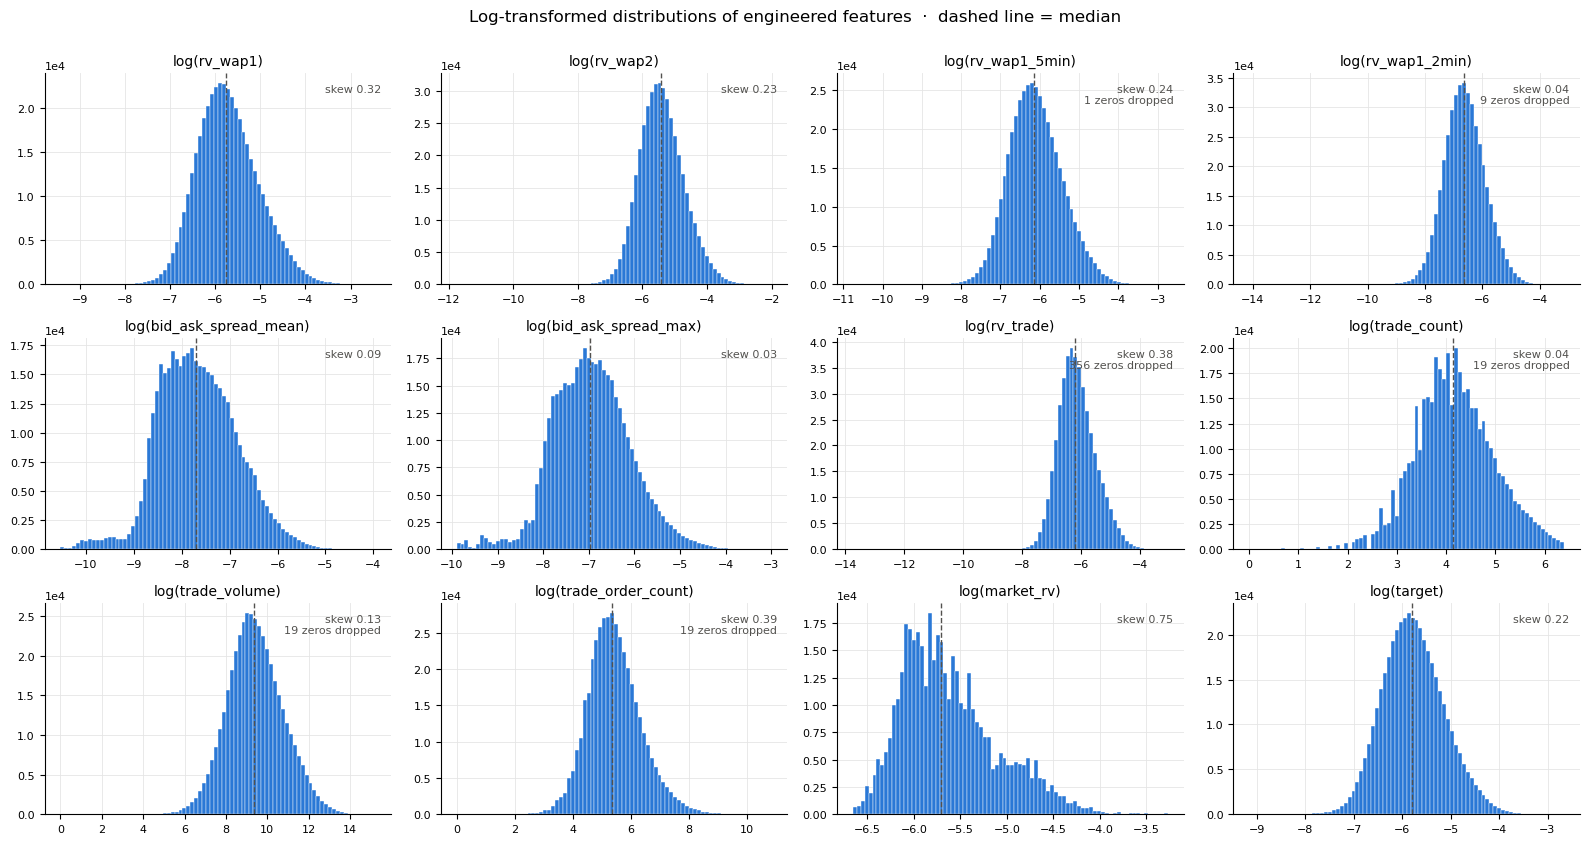

In [13]:
#log distributions
plot_distributions(df_features_train, plot_cols, log = True)

## 5 - Linear Regression with engineered features

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feature_cols = ['rv_wap1', 'rv_wap2', 'rv_wap1_5min', 'rv_wap1_2min',
                'bid_ask_spread_mean', 'bid_ask_spread_max',
                'rv_trade', 'trade_count', 'trade_volume', 'trade_order_count',
                'market_rv']

df = df_features_train.dropna(subset = feature_cols + ['target']).copy()

#counts/volumes: log1p handles windows with no trades (log1p(0) = 0)
count_cols = ['trade_count', 'trade_volume', 'trade_order_count']
#small-scale features (vol, spread): plain log; clip tiny values so zeros don't become huge outliers
small_cols = [c for c in feature_cols if c not in count_cols]

#log features due to skewed distributions
X_df = df[feature_cols].copy()
X_df[count_cols] = np.log1p(X_df[count_cols])
X_df[small_cols] = np.log(X_df[small_cols].clip(lower = 1e-4))
X = X_df[feature_cols].values
y = np.log(df['target'].values)

#same GroupKFold by time_id as before
oof = np.zeros(len(df))
for tr, va in GroupKFold(n_splits = 5).split(X, y, groups = df['time_id']):
    model = make_pipeline(StandardScaler(), LinearRegression()).fit(X[tr], y[tr])
    oof[va] = model.predict(X[va])

df['lr_feat_pred'] = np.exp(oof)
print(f"Linear regression (all features): R2 {r2_score(df['target'], df['lr_feat_pred']):.3f}, "
      f"RMSPE {rmspe(df['target'], df['lr_feat_pred']):.3f}")

#final model on all data - note: there is multicollinearity between features, so coefficient importance ranking below is not reliable
model = make_pipeline(StandardScaler(), LinearRegression()).fit(X, y)
pd.Series(model[-1].coef_, index = feature_cols).sort_values(key = abs, ascending = False)


Linear regression (all features): R2 0.797, RMSPE 0.270


bid_ask_spread_mean    0.157127
rv_wap2                0.149252
rv_wap1                0.132474
rv_wap1_5min           0.113848
trade_volume          -0.080704
trade_count            0.079665
trade_order_count      0.061601
rv_wap1_2min           0.043970
rv_trade               0.034955
bid_ask_spread_max    -0.023969
market_rv             -0.002873
dtype: float64

## 6 - Testing linear model

In [15]:
#1. build test features using the same functions as train (
list_book_test = glob.glob(f'{DATA_DIR}/book_test.parquet/*')
list_trade_test = glob.glob(f'{DATA_DIR}/trade_test.parquet/*')

df_book_features_test = pd.concat([book_features_per_time_id(f) for f in list_book_test], ignore_index = True)
df_trade_features_test = pd.concat([trade_features_per_time_id(f) for f in list_trade_test], ignore_index = True)

#2. merge onto test.csv
test = pd.read_csv(f'{DATA_DIR}/test.csv')
df_features_test = (test.merge(df_book_features_test, on = 'row_id', how = 'left')
                        .merge(df_trade_features_test, on = 'row_id', how = 'left'))
df_features_test[trade_cols] = df_features_test[trade_cols].fillna(0)
df_features_test['market_rv'] = df_features_test.groupby('time_id')['rv_wap1'].transform('mean')

#3. log transform; can't drop rows in test, so fill missing features with training medians
X_test_df = df_features_test[feature_cols].fillna(df_features_train[feature_cols].median())
X_test_df[count_cols] = np.log1p(X_test_df[count_cols])
X_test_df[small_cols] = np.log(X_test_df[small_cols].clip(lower = 1e-4))

#4. predict with the final linear model
df_features_test['target'] = np.exp(model.predict(X_test_df[feature_cols].values))

#linear predictions kept for comparison only; the LightGBM cell writes submission.csv
df_features_test[['row_id', 'target']]

,row_id,target
0,0-4,0.000392
1,0-32,0.002032
2,0-34,0.002032


## 7 - LightGBM with engineered features

In [16]:
import lightgbm as lgb

#trees split on thresholds, so no log transform or scaling needed -> use raw features
#add stock_id as a category so the model can learn each stock's typical volatility level
lgb_feature_cols = feature_cols + ['stock_id']
stock_categories = sorted(df['stock_id'].unique())

X_lgb = df[lgb_feature_cols].copy()
X_lgb['stock_id'] = pd.Categorical(X_lgb['stock_id'], categories = stock_categories)
y = np.log(df['target'].values)

params = {
    'objective': 'regression',
    'learning_rate': 0.05,
    'num_leaves': 63,          #max complexity of each tree
    'min_data_in_leaf': 100,   #each leaf needs 100+ rows -> less overfitting
    'feature_fraction': 0.8,   #each tree sees a random 80% of features
    'bagging_fraction': 0.8,   #each tree sees a random 80% of rows
    'bagging_freq': 1,
    'verbose': -1,
}

#same GroupKFold by time_id as linear regression, so scores are comparable
oof_lgb = np.zeros(len(df))
best_iters = []
for tr, va in GroupKFold(n_splits = 5).split(X_lgb, y, groups = df['time_id']):
    dtrain = lgb.Dataset(X_lgb.iloc[tr], y[tr])
    dvalid = lgb.Dataset(X_lgb.iloc[va], y[va])
    #keep adding trees until validation error stops improving for 100 rounds
    fold_model = lgb.train(params, dtrain, num_boost_round = 2000, valid_sets = [dvalid],
                           callbacks = [lgb.early_stopping(100), lgb.log_evaluation(200)])
    oof_lgb[va] = fold_model.predict(X_lgb.iloc[va], num_iteration = fold_model.best_iteration)
    best_iters.append(fold_model.best_iteration)

df['lgb_pred'] = np.exp(oof_lgb)
print(f"LightGBM: R2 {r2_score(df['target'], df['lgb_pred']):.3f}, "
      f"RMSPE {rmspe(df['target'], df['lgb_pred']):.3f}")
print('best iterations per fold:', best_iters)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.0590311
[400]	valid_0's l2: 0.0580727
[600]	valid_0's l2: 0.0577423
[800]	valid_0's l2: 0.0576017
[1000]	valid_0's l2: 0.0575317
[1200]	valid_0's l2: 0.0574927
Early stopping, best iteration is:
[1246]	valid_0's l2: 0.0574827
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.0602864
[400]	valid_0's l2: 0.0595801
[600]	valid_0's l2: 0.0593883
[800]	valid_0's l2: 0.0592846
Early stopping, best iteration is:
[797]	valid_0's l2: 0.0592818
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.0523044
[400]	valid_0's l2: 0.0518335
[600]	valid_0's l2: 0.05168
Early stopping, best iteration is:
[645]	valid_0's l2: 0.0516674
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.0515581
[400]	valid_0's l2: 0.0510962
[600]	valid_0's l2: 0.0509755
[800]	valid_0's l2: 0.0509656
Early stopping, best iteration is:
[809]	valid

In [17]:
#final model on all data, using the average number of trees the folds needed
lgb_model = lgb.train(params, lgb.Dataset(X_lgb, y), num_boost_round = int(np.mean(best_iters)))

#gain = how much each feature reduced the error in total across all splits
pd.Series(lgb_model.feature_importance('gain'), index = lgb_feature_cols).sort_values(ascending = False)


rv_wap1                789120.933938
rv_wap1_5min           249563.121768
rv_wap2                140699.803250
stock_id                28086.283253
market_rv               12750.333283
rv_wap1_2min            12370.263096
rv_trade                 5579.264250
trade_count              5104.798059
bid_ask_spread_mean      3886.017379
trade_order_count        3648.528895
bid_ask_spread_max       3629.624501
trade_volume             2403.293964
dtype: float64

In [18]:

pd.DataFrame({
    'RMSPE': [rmspe(df['target'], df['rv_wap1']),
              rmspe(df['target'], df['lr_feat_pred']),
              rmspe(df['target'], df['lgb_pred'])]
}, index = ['naive (past rv)', 'linear regression', 'LightGBM']).round(3)


,RMSPE
naive (past rv),0.341
linear regression,0.270
LightGBM,0.249


## 8 - Submission (LightGBM)
Final model: LightGBM (CV RMSPE 0.249). This cell writes `submission.csv`, which Kaggle scores.

In [19]:
#reuse df_features_test from the testing cell; LightGBM handles missing values itself, so no fillna needed
X_test_lgb = df_features_test[lgb_feature_cols].copy()
X_test_lgb['stock_id'] = pd.Categorical(X_test_lgb['stock_id'], categories = stock_categories)

df_features_test['target'] = np.exp(lgb_model.predict(X_test_lgb))
submission = df_features_test[['row_id', 'target']]
submission.to_csv('submission.csv', index = False)
submission


,row_id,target
0,0-4,0.001296
1,0-32,0.000676
2,0-34,0.000676
